In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

traj_dir = r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Mentor submissions\Pharma datasets\Process"
meta_dir = r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Mentor submissions\Pharma datasets"
lab_path = os.path.join(meta_dir, "Laboratory.csv")
fig_dir = os.path.join(meta_dir, "EDA_figures")
os.makedirs(fig_dir, exist_ok=True)

In [2]:
def read_csv(path):
    sep = ";" if open(path, errors="ignore").readline().count(";") > 0 else ","
    return pd.read_csv(path, sep=sep)

sensors = ["tbl_speed","fom","main_comp","tbl_fill","SREL","pre_comp","cyl_main","cyl_pre","stiffness","ejection"]

traj_files = sorted([f for f in glob.glob(os.path.join(traj_dir,"*.csv"))
                     if os.path.basename(f)[:-4].isdigit()],
                    key=lambda x: int(os.path.basename(x)[:-4]))
print(len(traj_files), "trajectory files found")

25 trajectory files found


In [3]:
rows = []
batch_len = []
for f in traj_files:
    code = int(os.path.basename(f)[:-4])
    df = read_csv(f)
    rows.append({"code": code, "total_rows": len(df), "n_batches": df["batch"].nunique()})
    for bid, g in df.groupby("batch"):
        batch_len.append({"batch": bid, "code": code, "length": len(g)})

fsum = pd.DataFrame(rows).sort_values("code")
blen = pd.DataFrame(batch_len)
print(fsum.to_string(index=False))
print("\nTotal batches:", len(blen), "| Total rows:", fsum["total_rows"].sum())

 code  total_rows  n_batches
    1      106878         95
    2      160513         17
    3       53057         16
    4       55973         22
    5       45547          3
    6       35609          2
    7       52687          8
    8       30174          2
    9        4664          4
   10      101306         27
   11       49264         15
   12      176044         21
   13      971164        131
   14      249320         11
   15      493017         64
   16       55171          2
   17      843959        207
   18        6596          1
   19       18502         17
   20       18132          4
   21       79070         68
   22      329989         41
   23      694893        187
   24       49135          6
   25       39544         34

Total batches: 1005 | Total rows: 4720208


Min 993 | Median 3228 | Mean 4696 | Max 41710


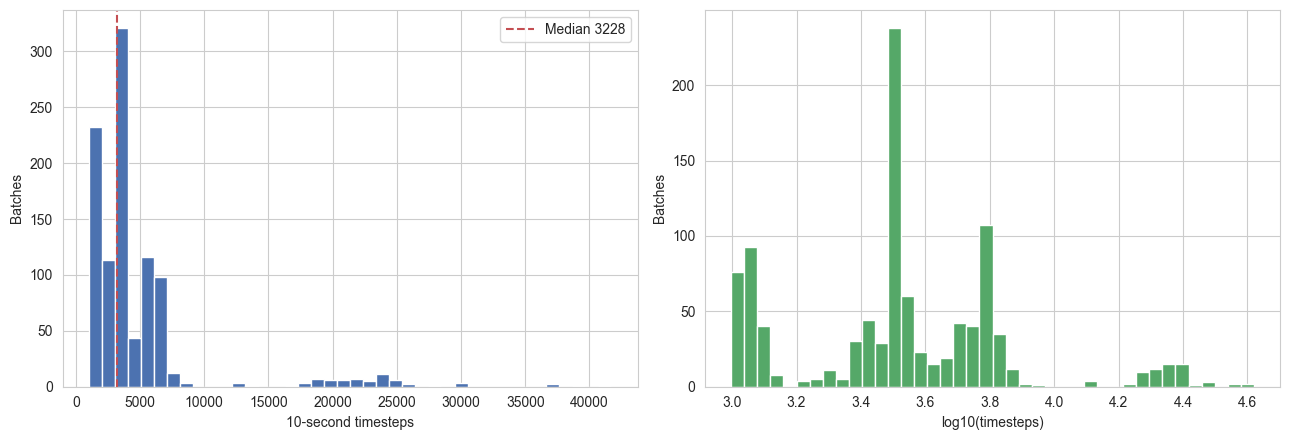

In [4]:
lengths = blen["length"].values
print("Min", lengths.min(), "| Median", int(np.median(lengths)), "| Mean", int(lengths.mean()), "| Max", lengths.max())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(lengths, bins=40, color="#4C72B0", edgecolor="white")
ax[0].axvline(np.median(lengths), color="#C44E52", ls="--", label=f"Median {int(np.median(lengths))}")
ax[0].set_xlabel("10-second timesteps"); ax[0].set_ylabel("Batches"); ax[0].legend()
ax[1].hist(np.log10(lengths), bins=40, color="#55A868", edgecolor="white")
ax[1].set_xlabel("log10(timesteps)"); ax[1].set_ylabel("Batches")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig1_lengths.png"), bbox_inches="tight")
plt.show()

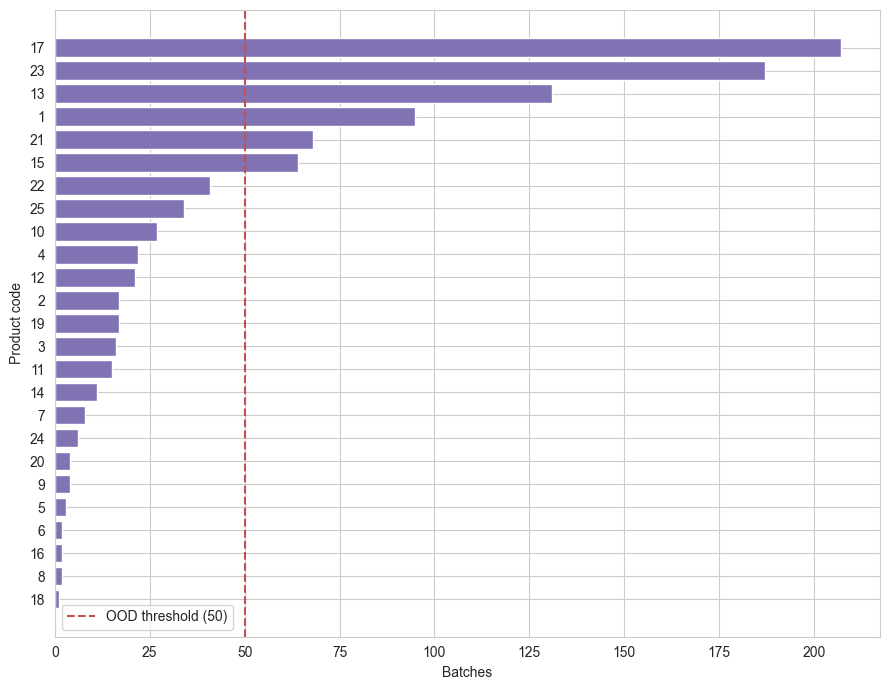

 code  n_batches
   17        207
   23        187
   13        131
    1         95
   21         68
   15         64
6 codes qualify for leave-one-code-out OOD


In [5]:
s = fsum.sort_values("n_batches")
plt.figure(figsize=(9, 7))
plt.barh(s["code"].astype(str), s["n_batches"], color="#8172B3")
plt.axvline(50, color="#C44E52", ls="--", label="OOD threshold (50)")
plt.xlabel("Batches"); plt.ylabel("Product code"); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig2_batches.png"), bbox_inches="tight")
plt.show()

ood = fsum[fsum["n_batches"] >= 50].sort_values("n_batches", ascending=False)
print(ood[["code","n_batches"]].to_string(index=False))
print(len(ood), "codes qualify for leave-one-code-out OOD")

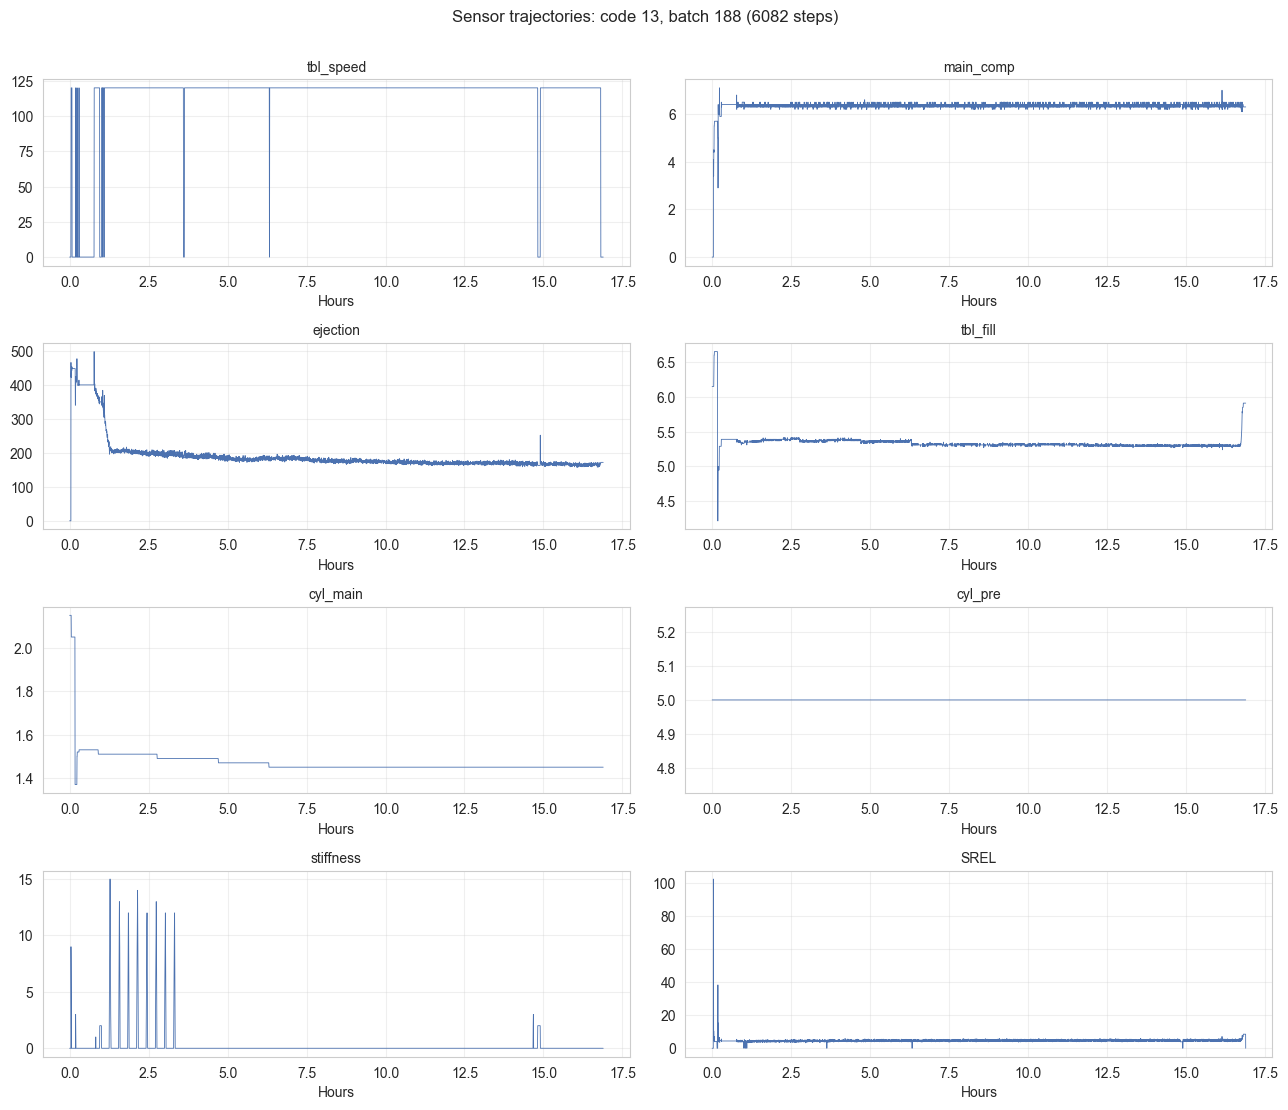

In [6]:
big = fsum.sort_values("total_rows").iloc[-1]["code"]
df = read_csv(os.path.join(traj_dir, f"{big}.csv"))
bid = df["batch"].iloc[0]
b = df[df["batch"] == bid].reset_index(drop=True)
t = np.arange(len(b)) * 10 / 3600

show = ["tbl_speed","main_comp","ejection","tbl_fill","cyl_main","cyl_pre","stiffness","SREL"]
fig, ax = plt.subplots(4, 2, figsize=(13, 11))
for a, col in zip(ax.flat, show):
    if col in b.columns:
        a.plot(t, b[col], color="#4C72B0", lw=0.6)
    a.set_title(col, fontsize=10); a.set_xlabel("Hours"); a.grid(alpha=0.3)
fig.suptitle(f"Sensor trajectories: code {big}, batch {bid} ({len(b)} steps)", y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig3_sensors.png"), bbox_inches="tight")
plt.show()

In [7]:
lab = pd.read_csv(lab_path, sep=";")
targets = ["dissolution_av","tbl_av_hardness","tbl_rsd_weight","fct_tensile"]
nice = {"dissolution_av":"Dissolution (%)","tbl_av_hardness":"Hardness (N)",
        "tbl_rsd_weight":"Weight RSD (%)","fct_tensile":"Tensile (MPa)"}
tgt = lab[targets].apply(pd.to_numeric, errors="coerce")

print(tgt.describe().round(2).to_string())
print("\nMissing values:")
for t in targets:
    print(f"  {t}: {tgt[t].isna().sum()} ({tgt[t].isna().mean()*100:.1f}%)")

       dissolution_av  tbl_av_hardness  tbl_rsd_weight  fct_tensile
count         1005.00          1005.00         1005.00      1005.00
mean            90.65            54.87            1.09         1.67
std              3.37            12.68            0.57         0.37
min             82.50            27.00            0.41         1.04
25%             88.33            49.00            0.83         1.35
50%             90.33            52.00            0.97         1.60
75%             92.83            56.00            1.17         1.96
max            102.67           102.00            9.90         3.04

Missing values:
  dissolution_av: 0 (0.0%)
  tbl_av_hardness: 0 (0.0%)
  tbl_rsd_weight: 0 (0.0%)
  fct_tensile: 0 (0.0%)


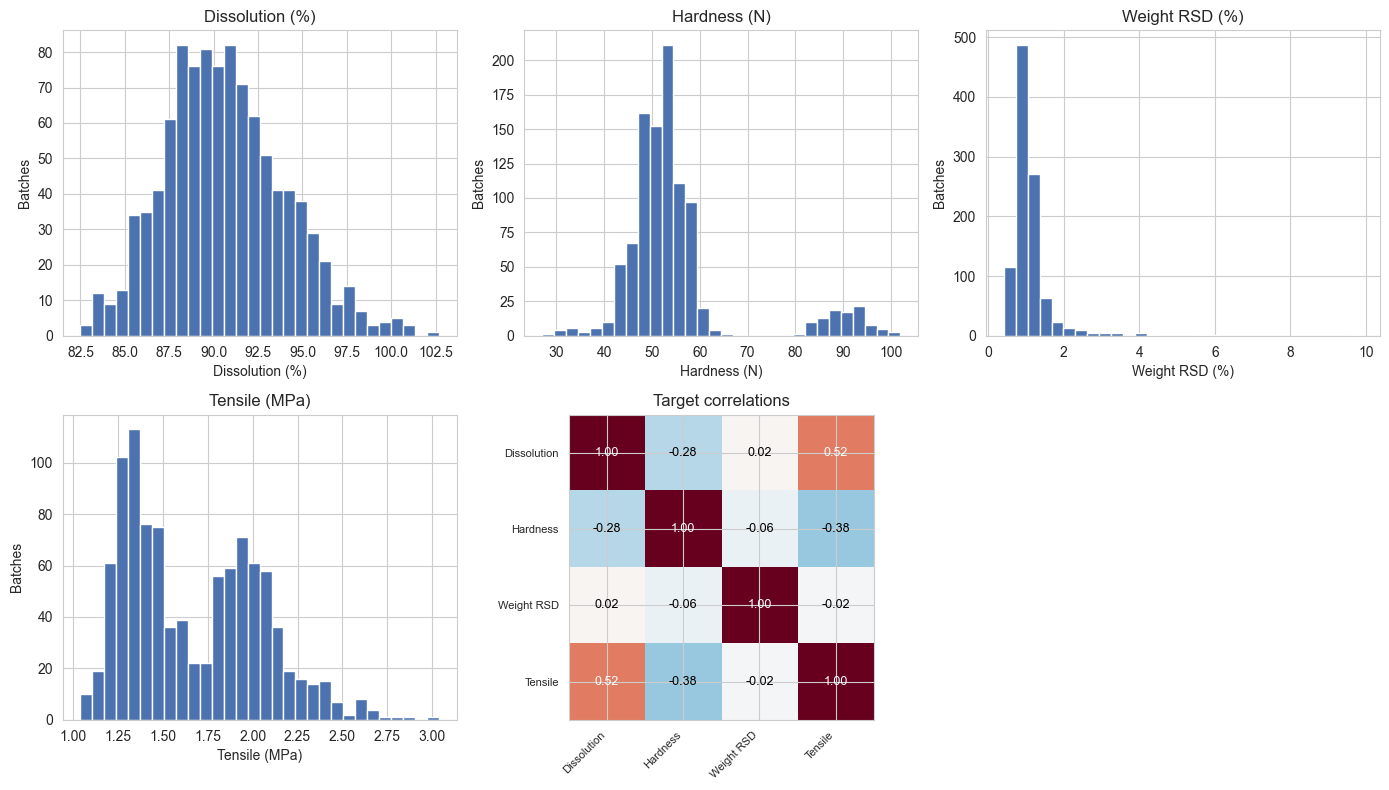

                 dissolution_av  tbl_av_hardness  tbl_rsd_weight  fct_tensile
dissolution_av            1.000           -0.282           0.018        0.517
tbl_av_hardness          -0.282            1.000          -0.064       -0.380
tbl_rsd_weight            0.018           -0.064           1.000       -0.017
fct_tensile               0.517           -0.380          -0.017        1.000


In [8]:
fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for a, t in zip(ax.flat[:4], targets):
    a.hist(tgt[t].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    a.set_title(nice[t]); a.set_xlabel(nice[t]); a.set_ylabel("Batches")

corr = tgt.corr()
a = ax.flat[4]
im = a.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
names = [nice[t].split(" (")[0] for t in targets]
a.set_xticks(range(4)); a.set_yticks(range(4))
a.set_xticklabels(names, rotation=45, ha="right", fontsize=8); a.set_yticklabels(names, fontsize=8)
for i in range(4):
    for j in range(4):
        a.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
               color="white" if abs(corr.iloc[i,j]) > 0.5 else "black", fontsize=9)
a.set_title("Target correlations")
ax.flat[5].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig4_targets.png"), bbox_inches="tight")
plt.show()
print(corr.round(3).to_string())

In [9]:
zeros = {s: [] for s in sensors}
for f in traj_files:
    df = read_csv(f)
    for col in sensors:
        if col in df.columns:
            zeros[col].append((df[col] == 0).mean() * 100)

for col in sensors:
    if zeros[col]:
        v = np.array(zeros[col])
        print(f"  {col}: mean {v.mean():.1f}% zeros (range {v.min():.0f}-{v.max():.0f}%)")

  tbl_speed: mean 32.6% zeros (range 13-64%)
  fom: mean 31.7% zeros (range 0-64%)
  main_comp: mean 0.6% zeros (range 0-3%)
  tbl_fill: mean 0.0% zeros (range 0-0%)
  SREL: mean 3.3% zeros (range 0-33%)
  pre_comp: mean 53.6% zeros (range 0-92%)
  cyl_main: mean 0.0% zeros (range 0-0%)
  cyl_pre: mean 0.0% zeros (range 0-0%)
  stiffness: mean 4.8% zeros (range 0-34%)
  ejection: mean 2.7% zeros (range 0-16%)
